In [21]:
import os
import xarray as xr
import functions.MLD_4grp as fl_mld
import matplotlib.pyplot as plt


In [3]:
# directories

data_dir = "/Users/smb-uh/UHM_Ocean_BGC_Group Dropbox/Datasets/"
cmip5_dir = data_dir + "Model_Output/CMIP5/"

In [11]:
so_file_list = []

for file in os.listdir(cmip5_dir + 'so/regrid_for_MLD/'):
    if file.endswith('.nc'):
        so_file_list.append(file)

thetao_file_list = []

for file in os.listdir(cmip5_dir + 'thetao/regrid_for_MLD/'):
    if file.endswith('.nc'):
        thetao_file_list.append(file)

In [12]:
print(so_file_list)
print(thetao_file_list)

['so_Omon_CMCC-CESM_rcp85_r1i1p1_200601-202012.nc']
['thetao_Omon_CMCC-CESM_rcp85_r1i1p1_200601-202012.nc']


In [16]:
so_n = xr.open_dataset(cmip5_dir + 'so/regrid_for_MLD/' + so_file_list[0])
thetao_n = xr.open_dataset(cmip5_dir + 'thetao/regrid_for_MLD/' + thetao_file_list[0])

In [ ]:
def calc_mld_wrapper(ds, r_depth, sig_threshold):
    mld_int = []
    for k in range(len(ds.N_PROF.values)):
        shallowest_depth = ds.isel(N_PROF=k).depth.values.min()
        # print(ds.isel(N_PROF=k).sigma0.count().values, "count values")
        if ds.isel(N_PROF=k).sigma0.count().values<50:
            mld=np.nan
        elif r_depth > shallowest_depth:
            mld = fl_mld.calc_mld(ds.isel(N_PROF=k), ref_depth=r_depth, sigma_theta_crit=sig_threshold)
        elif shallowest_depth > 50: # Shallowest depth level <50m so that MLD calc makes no sense; could change this
            mld = np.nan
        else:
            mld = fl_mld.calc_mld(ds.isel(N_PROF=k), ref_depth="shallowest", sigma_theta_crit=sig_threshold)
        mld_int.append(mld)
    # ds["mld"]= xr.DataArray(mld_int, coords=ds.coords, dims=["N_PROF"])
    mld_var = xr.DataArray(mld_int, coords={'N_PROF': ds['N_PROF']}, dims=['N_PROF'])
    ds['MLD'] = mld_var
    return ds 

In [17]:
print(so_n)
print(thetao_n)

<xarray.Dataset>
Dimensions:    (time: 120, bnds: 2, lon: 360, lat: 180, lev: 31)
Coordinates:
  * time       (time) datetime64[ns] 2010-01-16T12:00:00 ... 2019-12-16T12:00:00
  * lon        (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lev        (lev) float64 5.0 15.0 20.0 25.0 30.0 ... 700.0 800.0 900.0 1e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    so         (time, lev, lat, lon) float32 ...
Attributes: (12/30)
    CDI:                    Climate Data Interface version 2.1.1 (https://mpi...
    Conventions:            CF-1.4
    source:                 CMCC-CESM
    institution:            CMCC - Centro Euro-Mediterraneo per i Cambiamenti...
    institute_id:           CMCC
    experiment_id:          rcp85
    ...                     ...
    title:                  CMCC-CESM model output prepared for CMIP5 RCP8.5
    paren

In [ ]:
plt.

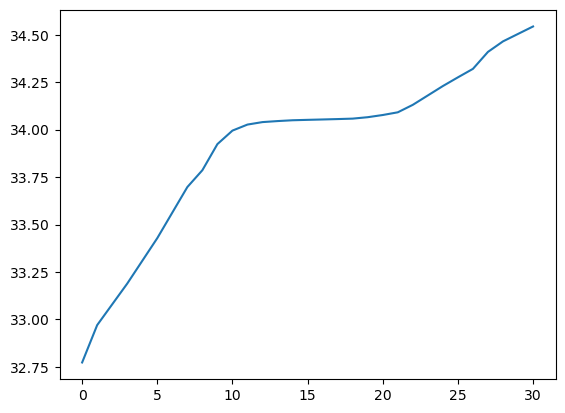

In [22]:
plt.plot(so_n.so[0,:,20,20])